# 02 · Un proceso gaussiano paso a paso: desde cero, con scikit-learn, y con dos kernels

**Pregunta de la clase.** Una ciudad pequeña registra su demanda eléctrica diaria (MW). Tenemos 4 semanas de datos, con un hueco
de 3 días en que falló el medidor. **¿Cuánta capacidad debemos reservar para la próxima semana?**

Para responder no basta una curva: necesitamos la curva **y su margen de error**. Eso es lo que da un proceso gaussiano (GP).

| Paso | Qué hacemos | min |
|---|---|---|
| 0 | Los datos y la pregunta | 5 |
| 1 | El kernel: nuestra única hipótesis | 7 |
| 2 | El GP antes de ver datos | 5 |
| 3 | El GP después de ver datos, línea por línea | 18 |
| 4 | La respuesta | 5 |
| 5 | Lo mismo con scikit-learn | 7 |
| 6 | Sumar dos kernels | 13 |

> Los nombres de las variables (`kxx`, `kXX`, `B1`…`B4`, `R`, `A`, `mpost`, `vpost`, `spost`, `stdpo`) son los mismos del código
> MATLAB de la presentación, para leerlos lado a lado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
AZUL, ORO, GRIS = "#003D79", "#D59F0F", "#8A8F98"   # colores UNAM
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

## Paso 0 · Los datos y la pregunta

Datos **sintéticos**: así todos tenemos la misma serie y podemos esconder el futuro y luego destaparlo. La serie tiene tres ingredientes
(los recordaremos en el Paso 6): una **tendencia** (ola de calor, sube ~25 MW), un **vaivén** que se repite cada 14 días (±5 MW) y **ruido** de medición (±2.5 MW).
Escondemos la próxima semana (días 28–34) y tres días de medidor descompuesto (12–14).

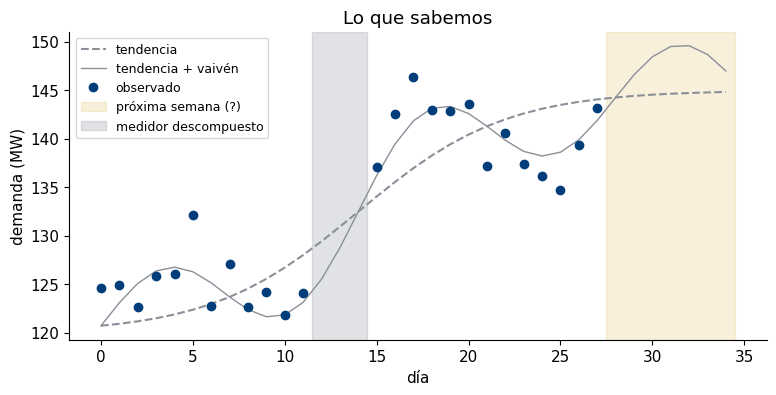

25 días observados, 10 sin dato


In [2]:
def demanda_ciudad(dias=35, semilla=30):
    rng = np.random.default_rng(semilla)
    t = np.arange(dias, dtype=float)
    tendencia = 120 + 25 / (1 + np.exp(-(t - 14) / 4))    # ola de calor
    vaiven    = 5 * np.sin(2 * np.pi * t / 14)             # se repite cada 14 días
    ruido     = rng.normal(0, 2.5, dias)                   # error de medición
    return t, tendencia + vaiven + ruido, tendencia, vaiven

t, y, tendencia, vaiven = demanda_ciudad()
observado = np.ones(len(t), dtype=bool); observado[28:] = False; observado[12:15] = False
X, Y = t[observado], y[observado]      # mayúsculas: los DATOS (como en el código MATLAB)

plt.plot(t, tendencia, color=GRIS, ls="--", label="tendencia"); plt.plot(t, tendencia + vaiven, color=GRIS, lw=1, label="tendencia + vaivén")
plt.plot(X, Y, "o", color=AZUL, label="observado")
plt.axvspan(27.5, 34.5, color=ORO, alpha=0.15, label="próxima semana (?)"); plt.axvspan(11.5, 14.5, color=GRIS, alpha=0.25, label="medidor descompuesto")
plt.xlabel("día"); plt.ylabel("demanda (MW)"); plt.legend(loc="upper left", fontsize=9); plt.title("Lo que sabemos")
plt.show()
print(f"{len(X)} días observados, {(~observado).sum()} sin dato")

**La apuesta.** Antes de hacer cuentas: a ojo, ¿cuánta capacidad reservarías para la próxima semana? Anota un número y un rango en papel.

## Paso 1 · El kernel: ¿cuánto se parecen dos días?

Un GP no supone una fórmula para la curva. Supone algo más humilde: **qué tan parecidos son los valores de dos días según qué tan lejos están**.
Esa regla es el **kernel**. Hoy empezamos con el RBF:

$$k(t, t') = \sigma_f^2 \, \exp\!\left(-\frac{(t-t')^2}{2\ell^2}\right)$$

| Símbolo | Qué controla | Hoy |
|---|---|---|
| $\ell$ | a cuántos días de distancia dos demandas dejan de parecerse | 5 días |
| $\sigma_f$ | cuánto puede subir o bajar la curva alrededor de su media | la desviación estándar de los datos |
| $\sigma_n$ (fuera del kernel) | cuánto error trae cada medición | 2.5 MW |

Son los **hiperparámetros**: hoy a mano; en el Paso 5 scikit-learn los aprende solo. La figura muestra el efecto de ℓ: parecido del día 10 con cualquier otro.

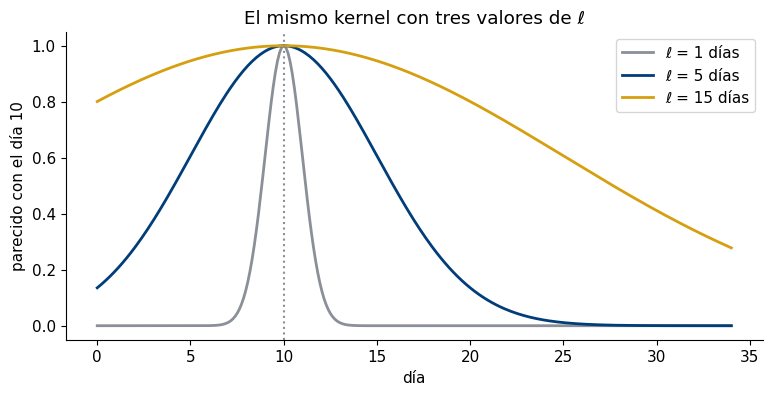

kXX: (25, 25) | un día consigo mismo: 68.5 | día 0 con día 1: 67.2 | día 0 con día 10: 9.3


In [3]:
ell, sigma_n = 5.0, 2.5
sigma_f = Y.std()
b = Y.mean()            # media a priori: sin datos, apostamos al promedio (MATLAB: b = mean(Y))

def k(a, c):
    # Kernel RBF entre todos los pares de días de `a` y de `c`. Devuelve una matriz len(a) x len(c).
    return sigma_f**2 * np.exp(-0.5 * (a[:, None] - c[None, :])**2 / ell**2)

d = np.linspace(0, 34, 300)
for ell_prueba, color in [(1.0, GRIS), (5.0, AZUL), (15.0, ORO)]:
    plt.plot(d, np.exp(-0.5 * (10 - d)**2 / ell_prueba**2), color=color, lw=2, label=f"ℓ = {ell_prueba:.0f} días")
plt.axvline(10, color=GRIS, ls=":"); plt.xlabel("día"); plt.ylabel("parecido con el día 10"); plt.legend(); plt.title("El mismo kernel con tres valores de ℓ")
plt.show()
kXX = k(X, X)
print("kXX:", kXX.shape, "| un día consigo mismo:", round(kXX[0, 0], 1), "| día 0 con día 1:", round(kXX[0, 1], 1), "| día 0 con día 10:", round(kXX[0, 10], 1))

## Paso 2 · El GP antes de ver datos (a priori)

Con el kernel construimos la matriz de parecidos entre todos los días de la malla donde queremos predecir ($k_{xx}$) y *sorteamos* curvas posibles.
Para que los números sorteados se parezcan entre días vecinos, se usa la "raíz cuadrada" de la matriz: la **descomposición de Cholesky** $L$ ($LL^\top = k_{xx}$):
`curva = m + L @ ruido`. Sin $L$ saldría ruido puro; con $L$ salen curvas suaves.

```matlab
kxx = phix * Sigma * phix';   s = bsxfun(@plus, m, chol(kxx + 1e-8*eye(n))' * randn(n,funct));   stdpi = sqrt(diag(kxx));
```

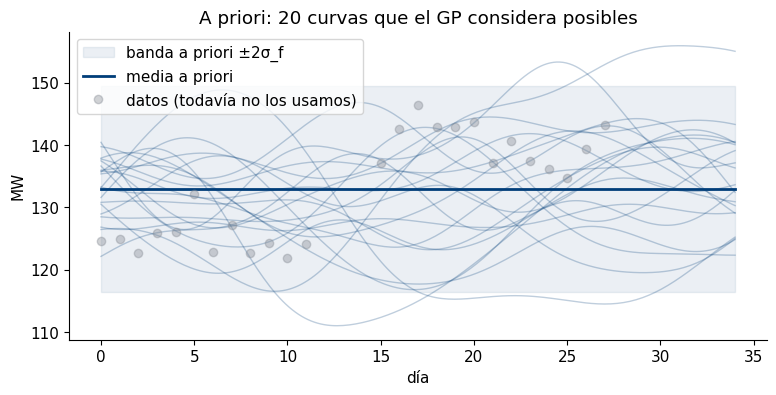

In [4]:
n = 200; funct = 20
x = np.linspace(0, 34, n)                                # minúscula: la malla donde PREDECIMOS
m   = np.full(n, b)                                      # media a priori
kxx = k(x, x)                                            # matriz n x n de parecidos          (MATLAB: kxx)
L   = np.linalg.cholesky(kxx + 1e-8 * np.eye(n))         # "raíz" de la matriz  (MATLAB: chol(...)')
s   = m[:, None] + L @ np.random.default_rng(1).normal(size=(n, funct))    # 20 curvas a priori
stdpi = np.sqrt(np.diag(kxx))                            # desviación a priori = σ_f en todos los días

plt.plot(x, s, color=AZUL, alpha=0.25, lw=1)
plt.fill_between(x, m - 2*stdpi, m + 2*stdpi, color=AZUL, alpha=0.08, label="banda a priori ±2σ_f")
plt.plot(x, m, color=AZUL, lw=2, label="media a priori"); plt.plot(X, Y, "o", color=GRIS, alpha=0.4, label="datos (todavía no los usamos)")
plt.xlabel("día"); plt.ylabel("MW"); plt.legend(loc="upper left"); plt.title("A priori: 20 curvas que el GP considera posibles")
plt.show()

Suaves (por ℓ = 5), alrededor del promedio con amplitud σ_f, y ninguna pasa por los datos: **todavía no se los hemos enseñado**.

## Paso 3 · El GP después de ver datos, línea por línea

El corazón del método. En MATLAB:

```matlab
B1 = phix * mu;                  % media a priori en la malla
B2 = phix * Sigma * phiX';       % kxX : parecido entre malla y datos
B3 = kXX + sigma^2 * eye(N);     % G   : parecido entre datos, más el ruido del medidor
R  = chol(B3);
B4 = Y' - M;                     % datos menos la media
A  = B2 / R;
mpost = B1 + A * (R' \ B4);      % media a posteriori
vpost = kxx - A * A';            % covarianza a posteriori
```

### 3a · Las tres matrices de entrada
- **`B1`**: lo que creeríamos sin datos: el promedio en todos los días de la malla.
- **`B2`**: a qué datos se parece cada día de la malla (kernel malla × datos).
- **`B3`**: cuánto se parecen los datos entre sí, con $\sigma_n^2$ sumado en la diagonal: "ni un día consigo mismo es exacto". Es lo que impide que la curva pase *exactamente* por cada punto.

In [5]:
N  = len(X)
B1 = np.full(n, b)                                   # (MATLAB: B1 = phix*mu)
B2 = k(x, X)                                         # kxX: malla vs datos               (MATLAB: B2)
B3 = kXX + sigma_n**2 * np.eye(N)                    # G: datos vs datos + ruido         (MATLAB: B3)
print("B1:", B1.shape, " B2:", B2.shape, " B3:", B3.shape)
print("diagonal de kXX:", round(kXX[0, 0], 1), "→ diagonal de B3:", round(B3[0, 0], 1), " (se sumó σ_n² =", sigma_n**2, ")")

B1: (200,)  B2: (200, 25)  B3: (25, 25)
diagonal de kXX: 68.5 → diagonal de B3: 74.8  (se sumó σ_n² = 6.25 )


### 3b · Resolver: `R`, `B4`, `A`
- **`R`**: Cholesky de B3. Sirve para **resolver** con B3 sin invertirla (MATLAB devuelve la triangular superior; NumPy la inferior, de ahí el `.T`).
- **`B4`**: cuánto se desviaron los datos de la media a priori.
- **`A`**: combina B2 y B3 en **pesos**: cuánto influye cada dato en cada día de la malla. La figura muestra los pesos para predecir el día 30:
  mandan los días 26 y 27, y algunos pesos son negativos (el GP corrige con datos que se parecen mucho entre sí).

R.T @ R == B3: True | B4 (MW): [ -8.3  -8.  -10.3  -7.1  -6.9] ... | A: (200, 25)


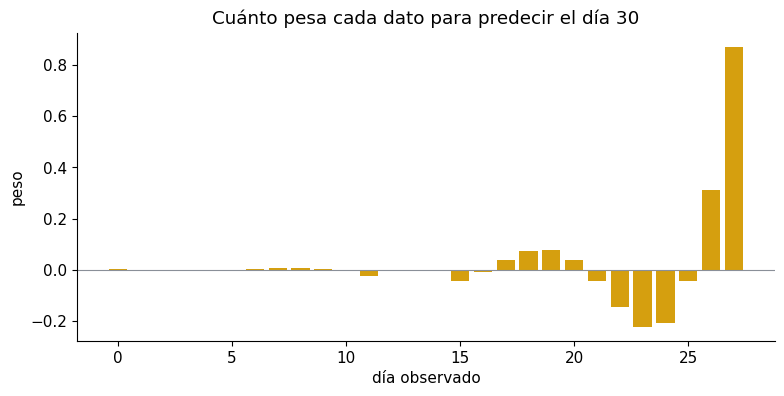

In [6]:
R  = np.linalg.cholesky(B3).T                        # (MATLAB: R = chol(B3))
M  = np.full(N, b); B4 = Y - M                       # (MATLAB: B4 = Y' - M)
A  = np.linalg.solve(R.T, B2.T).T                    # A = B2 / R   (resolver, nunca invertir)
print("R.T @ R == B3:", np.allclose(R.T @ R, B3), "| B4 (MW):", np.round(B4[:5], 1), "... | A:", A.shape)

i30 = np.argmin(np.abs(x - 30))
pesos = (A @ np.linalg.solve(R.T, np.eye(N)))[i30]   # pesos efectivos de cada dato para el día 30
plt.bar(X, pesos, width=0.8, color=ORO); plt.axhline(0, color=GRIS, lw=0.8)
plt.xlabel("día observado"); plt.ylabel("peso"); plt.title("Cuánto pesa cada dato para predecir el día 30")
plt.show()

### 3c · El resultado: `mpost`, `vpost`, `stdpo`, `spost`
- **`mpost`** = media a priori **más** pesos × desviaciones: la curva.
- **`vpost`** = incertidumbre a priori **menos** lo que los datos enseñaron. Los datos solo pueden *restar* incertidumbre. Su diagonal con raíz es **`stdpo`**, la desviación en cada día.
- **`spost`**: las 20 curvas del Paso 2, ahora obligadas a pasar cerca de los datos.

Mira tres cosas en la figura: la banda angosta donde hay datos, el hueco que se abre y se cierra (el GP **interpola** con honestidad), y la próxima semana que se abre cada día más (el GP **sabe que no sabe**).

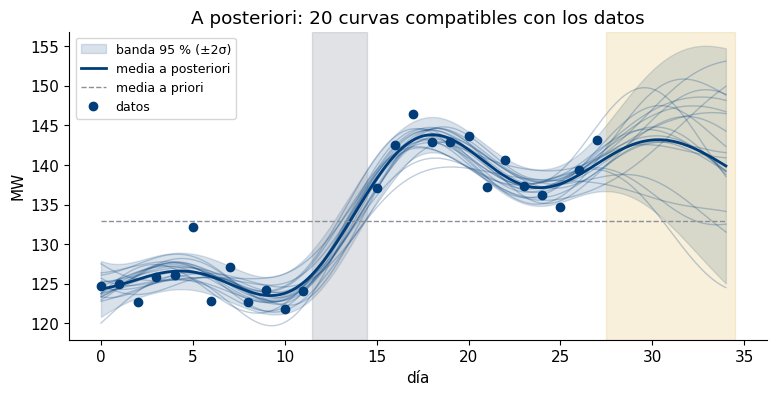

desviación a posteriori: con datos ≈ 1.2 MW | en el hueco ≈ 1.6 MW | día 34 ≈ 7.4 MW  (a priori era 8.3 )


In [7]:
mpost = B1 + A @ np.linalg.solve(R.T, B4)             # media a posteriori
vpost = kxx - A @ A.T                                 # covarianza a posteriori
stdpo = np.sqrt(np.diag(vpost))                       # desviación a posteriori en cada día
spost = mpost[:, None] + np.linalg.cholesky(vpost + 1e-8 * np.eye(n)) @ np.random.default_rng(2).normal(size=(n, funct))

plt.plot(x, spost, color=AZUL, alpha=0.25, lw=1)
plt.fill_between(x, mpost - 2*stdpo, mpost + 2*stdpo, color=AZUL, alpha=0.15, label="banda 95 % (±2σ)")
plt.plot(x, mpost, color=AZUL, lw=2, label="media a posteriori"); plt.plot(x, B1, color=GRIS, ls="--", lw=1, label="media a priori")
plt.plot(X, Y, "o", color=AZUL, label="datos")
plt.axvspan(27.5, 34.5, color=ORO, alpha=0.15); plt.axvspan(11.5, 14.5, color=GRIS, alpha=0.25)
plt.xlabel("día"); plt.ylabel("MW"); plt.legend(loc="upper left", fontsize=9); plt.title("A posteriori: 20 curvas compatibles con los datos")
plt.show()
print("desviación a posteriori: con datos ≈", round(stdpo[100], 1), "MW | en el hueco ≈", round(stdpo[np.argmin(np.abs(x-13))], 1), "MW | día 34 ≈", round(stdpo[-1], 1), "MW  (a priori era", round(stdpi[0], 1), ")")

## Paso 4 · La respuesta a la pregunta

La banda superior del 95 % en la próxima semana es un número defendible. Y ahora sí, destapamos la semana escondida.

Pico esperado 143.2 MW | capacidad a reservar (95 %) 155.0 MW | margen que compra la incertidumbre 11.9 MW


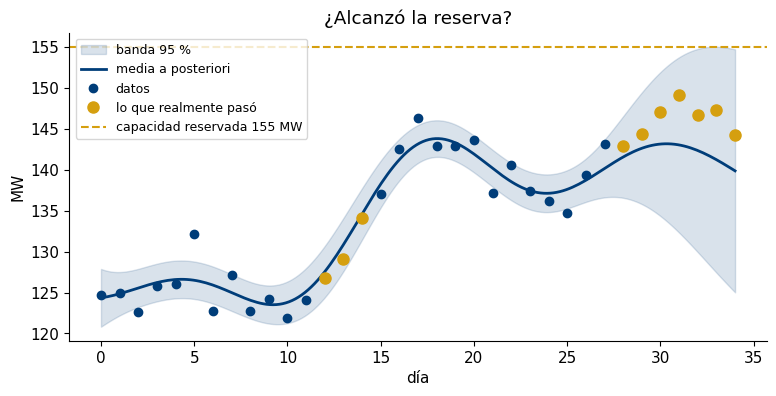

Días ocultos dentro de la banda: 10 de 10 · pico real de la semana: 149.1 MW. Compara con tu apuesta.


In [8]:
futuro = x >= 28
pico_esperado = mpost[futuro].max()
capacidad_95  = (mpost + 2*stdpo)[futuro].max()
print(f"Pico esperado {pico_esperado:.1f} MW | capacidad a reservar (95 %) {capacidad_95:.1f} MW | margen que compra la incertidumbre {capacidad_95 - pico_esperado:.1f} MW")

plt.fill_between(x, mpost - 2*stdpo, mpost + 2*stdpo, color=AZUL, alpha=0.15, label="banda 95 %")
plt.plot(x, mpost, color=AZUL, lw=2, label="media a posteriori"); plt.plot(X, Y, "o", color=AZUL, label="datos")
plt.plot(t[~observado], y[~observado], "o", color=ORO, markersize=8, label="lo que realmente pasó")
plt.axhline(capacidad_95, color=ORO, ls="--", label=f"capacidad reservada {capacidad_95:.0f} MW")
plt.xlabel("día"); plt.ylabel("MW"); plt.legend(loc="upper left", fontsize=9); plt.title("¿Alcanzó la reserva?")
plt.show()
dentro = np.abs(y[~observado] - np.interp(t[~observado], x, mpost)) <= 2*np.interp(t[~observado], x, stdpo)
print(f"Días ocultos dentro de la banda: {dentro.sum()} de {dentro.size} · pico real de la semana: {y[28:].max():.1f} MW. Compara con tu apuesta.")

## Paso 5 · Lo mismo con scikit-learn, en 3 líneas

Le damos el **mismo kernel** con los **mismos hiperparámetros** y le pedimos que no los cambie (`optimizer=None`). Detalles de traducción:
scikit espera los datos como columna (`X[:, None]`), `alpha` es la varianza del ruido ($\sigma_n^2$), y la media `b` la restamos y sumamos nosotros.
Después, quitando `optimizer=None`, **aprende los hiperparámetros solo** (maximiza la verosimilitud marginal).

Diferencia máxima desde cero vs scikit-learn — media: 2.8e-14 MW, desviación: 2.8e-14 MW  → es el mismo cálculo
Kernel aprendido: 8.32**2 * RBF(length_scale=4.15) → ℓ = 4.15 días (a mano: 5); capacidad 95 %: 154.5 MW (a mano: 155.0)


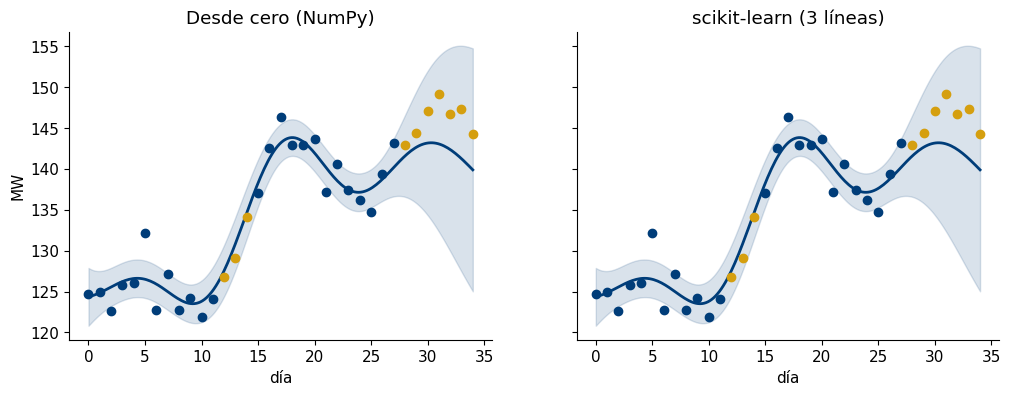

In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

kernel = ConstantKernel(sigma_f**2, "fixed") * RBF(length_scale=ell, length_scale_bounds="fixed")
gp = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, optimizer=None).fit(X[:, None], Y - b)
m_skl, s_skl = gp.predict(x[:, None], return_std=True); m_skl = m_skl + b
print(f"Diferencia máxima desde cero vs scikit-learn — media: {np.abs(mpost - m_skl).max():.1e} MW, desviación: {np.abs(stdpo - s_skl).max():.1e} MW  → es el mismo cálculo")

gp_libre = GaussianProcessRegressor(kernel=ConstantKernel(sigma_f**2) * RBF(length_scale=ell), alpha=sigma_n**2, n_restarts_optimizer=5, random_state=0).fit(X[:, None], Y - b)
m_lib, s_lib = gp_libre.predict(x[:, None], return_std=True); m_lib += b
print("Kernel aprendido:", gp_libre.kernel_, f"→ ℓ = {gp_libre.kernel_.k2.length_scale:.2f} días (a mano: {ell:.0f}); capacidad 95 %: {(m_lib + 2*s_lib)[futuro].max():.1f} MW (a mano: {capacidad_95:.1f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for a_, mm, ss, titulo in [(ax[0], mpost, stdpo, "Desde cero (NumPy)"), (ax[1], m_skl, s_skl, "scikit-learn (3 líneas)")]:
    a_.fill_between(x, mm - 2*ss, mm + 2*ss, color=AZUL, alpha=0.15); a_.plot(x, mm, color=AZUL, lw=2); a_.plot(X, Y, "o", color=AZUL)
    a_.plot(t[~observado], y[~observado], "o", color=ORO); a_.set_title(titulo); a_.set_xlabel("día")
ax[0].set_ylabel("MW"); plt.show()

## Paso 6 · Sumar dos kernels

La serie tiene una **tendencia** suave y un **vaivén que se repite cada 14 días**. Con un solo RBF, el vaivén se trata como ruido y hacia el futuro el GP no sabe que se repetirá.

Los kernels **se suman**: $k = k_{\text{RBF}} + k_{\text{per}}$. Sumar kernels es sumar hipótesis: "la curva es una parte suave **más** una parte que se repite".
El periódico:

$$k_{\text{per}}(t,t') = \sigma_p^2 \exp\!\left(-\frac{2\sin^2(\pi\,|t-t'|/P)}{\ell_p^2}\right)\qquad P = 14 \text{ días},\ \sigma_p = 5 \text{ MW},\ \ell_p = 1$$

Al RBF le damos ℓ = 10: ya no tiene que perseguir el vaivén, solo la tendencia. En la tercera gráfica, el día 10 se parece a sus vecinos (RBF) **y además** a los días 24 y 38 (periódico).

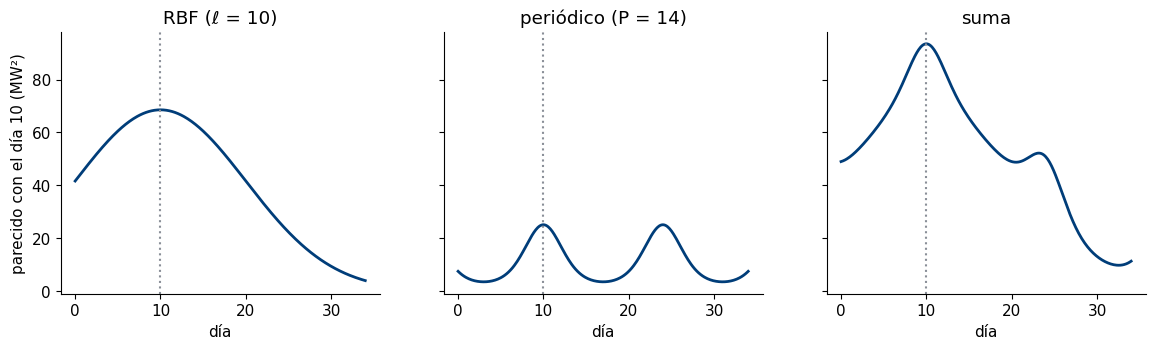

In [10]:
P, sigma_p, ell_p = 14.0, 5.0, 1.0
def k_per(a, c):       return sigma_p**2 * np.exp(-2 * np.sin(np.pi * np.abs(a[:, None] - c[None, :]) / P)**2 / ell_p**2)
def k_rbf_largo(a, c): return sigma_f**2 * np.exp(-0.5 * (a[:, None] - c[None, :])**2 / 10.0**2)
def k_dos(a, c):       return k_rbf_largo(a, c) + k_per(a, c)          # ← la suma

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for a_, kk, titulo in [(ax[0], k_rbf_largo, "RBF (ℓ = 10)"), (ax[1], k_per, "periódico (P = 14)"), (ax[2], k_dos, "suma")]:
    a_.plot(d, kk(np.array([10.0]), d)[0], color=AZUL, lw=2); a_.axvline(10, color=GRIS, ls=":"); a_.set_title(titulo); a_.set_xlabel("día")
ax[0].set_ylabel("parecido con el día 10 (MW²)"); plt.show()

Las mismas seis líneas del Paso 3, empaquetadas en una función que recibe el kernel, y la comparación un kernel vs dos.

la función reproduce el Paso 3: True


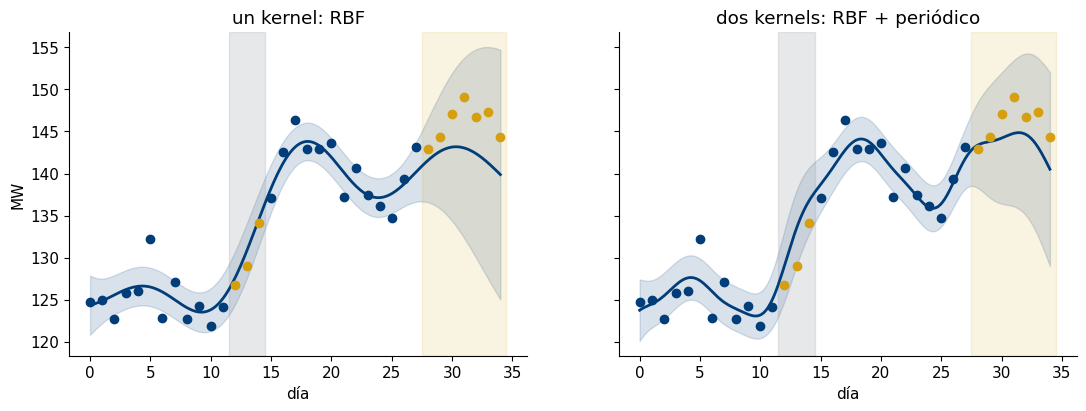

RBF               reserva 95 %  155.0 MW | error medio en la semana oculta  4.0 MW | ancho medio de la banda 20.7 MW
RBF + periódico   reserva 95 %  154.3 MW | error medio en la semana oculta  2.6 MW | ancho medio de la banda 17.1 MW


In [11]:
def posterior(kfun):
    # Las seis líneas del Paso 3, para cualquier kernel kfun(a, c)
    B2 = kfun(x, X); B3 = kfun(X, X) + sigma_n**2 * np.eye(N); R = np.linalg.cholesky(B3).T
    A  = np.linalg.solve(R.T, B2.T).T
    return b + A @ np.linalg.solve(R.T, Y - b), np.sqrt(np.clip(np.diag(kfun(x, x) - A @ A.T), 0, None))

m_uno, s_uno = posterior(k)          # un kernel  (reproduce el Paso 3)
m_dos, s_dos = posterior(k_dos)      # dos kernels
print("la función reproduce el Paso 3:", np.allclose(m_uno, mpost) and np.allclose(s_uno, stdpo))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for a_, mm, ss, titulo in [(ax[0], m_uno, s_uno, "un kernel: RBF"), (ax[1], m_dos, s_dos, "dos kernels: RBF + periódico")]:
    a_.fill_between(x, mm - 2*ss, mm + 2*ss, color=AZUL, alpha=0.15); a_.plot(x, mm, color=AZUL, lw=2); a_.plot(X, Y, "o", color=AZUL)
    a_.plot(t[~observado], y[~observado], "o", color=ORO); a_.axvspan(27.5, 34.5, color=ORO, alpha=0.12); a_.axvspan(11.5, 14.5, color=GRIS, alpha=0.2)
    a_.set_title(titulo); a_.set_xlabel("día")
ax[0].set_ylabel("MW"); plt.show()

real = y[28:]
for nombre, mm, ss in [("RBF", m_uno, s_uno), ("RBF + periódico", m_dos, s_dos)]:
    mf, sf_ = np.interp(t[28:], x, mm), np.interp(t[28:], x, ss)
    print(f"{nombre:<17} reserva 95 % {(mm + 2*ss)[futuro].max():6.1f} MW | error medio en la semana oculta {np.abs(real - mf).mean():4.1f} MW | ancho medio de la banda {(4*sf_).mean():4.1f} MW")

Qué cambió: en el hueco y en la semana futura la media ya sigue el vaivén (error medio menor) y la banda es más angosta. Cuidado: una banda angosta
solo es buena si la hipótesis es cierta; si la serie no fuera periódica, este kernel nos haría **confiar de más**.

Los kernels no compiten, se reparten el trabajo. La media a posteriori se puede separar en sus dos partes (cada una con su kernel y los mismos pesos):

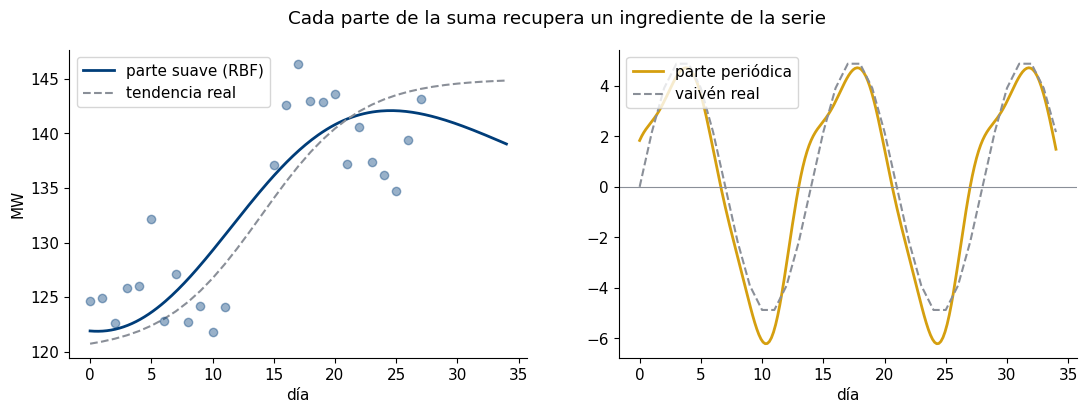

scikit-learn con RBF + ExpSineSquared vs nuestra suma — media: 5.7e-14 MW, desviación: 2.2e-14 MW


In [12]:
pesos_dos = np.linalg.solve(k_dos(X, X) + sigma_n**2 * np.eye(N), Y - b)      # = inv(B3) @ B4, común a las dos partes
parte_suave, parte_periodica = b + k_rbf_largo(x, X) @ pesos_dos, k_per(x, X) @ pesos_dos

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(x, parte_suave, color=AZUL, lw=2, label="parte suave (RBF)"); ax[0].plot(t, tendencia, color=GRIS, ls="--", label="tendencia real")
ax[0].plot(X, Y, "o", color=AZUL, alpha=0.4); ax[0].legend(loc="upper left"); ax[0].set_xlabel("día"); ax[0].set_ylabel("MW")
ax[1].plot(x, parte_periodica, color=ORO, lw=2, label="parte periódica"); ax[1].plot(t, vaiven, color=GRIS, ls="--", label="vaivén real")
ax[1].axhline(0, color=GRIS, lw=0.8); ax[1].legend(loc="upper left"); ax[1].set_xlabel("día")
plt.suptitle("Cada parte de la suma recupera un ingrediente de la serie"); plt.show()

from sklearn.gaussian_process.kernels import ExpSineSquared     # en scikit-learn, sumar kernels es un +
k_skl_dos = ConstantKernel(sigma_f**2, "fixed") * RBF(10.0, "fixed") + ConstantKernel(sigma_p**2, "fixed") * ExpSineSquared(ell_p, P, "fixed", "fixed")
m_skl_dos, s_skl_dos = GaussianProcessRegressor(kernel=k_skl_dos, alpha=sigma_n**2, optimizer=None).fit(X[:, None], Y - b).predict(x[:, None], return_std=True)
print(f"scikit-learn con RBF + ExpSineSquared vs nuestra suma — media: {np.abs(m_dos - (m_skl_dos + b)).max():.1e} MW, desviación: {np.abs(s_dos - s_skl_dos).max():.1e} MW")

## Lo que aprendimos

**Un proceso gaussiano es:** un kernel (la hipótesis de parecido) + seis líneas de álgebra que actualizan esa hipótesis con los datos.
Devuelve una curva **y** su margen de error, y el margen es la respuesta a preguntas de planeación ("¿cuánto reservo?").

| | Desde cero | scikit-learn |
|---|---|---|
| Líneas | ~15 | 3 |
| Entiendes qué pasa | sí | solo si hiciste lo anterior |
| Aprende hiperparámetros | no (a mano) | sí |
| Sumar kernels | sumar dos funciones | un `+` |
| Resultado | idéntico | idéntico |

**Tarea** (`03_tarea.ipynb`): la misma ciudad, ahora con **ritmo semanal** (los fines de semana baja la demanda): suma de kernels con periodo de 7 días,
dejando que scikit-learn aprenda los hiperparámetros.

---
### Apéndice (opcional, no se ve en clase): la versión literal del código MATLAB

El código de la presentación no escribe el kernel directo; lo construye con **1000 "campanas"** $\phi$ centradas en una malla y define $k = \phi \, \Sigma \, \phi^\top$
(la *vista de características* del mismo GP). Traducido línea por línea, da la misma banda.

In [13]:
F = 1000
centros = np.linspace(-5, 39, F)
ell_phi = ell / np.sqrt(2)                                          # sumar campanas de ancho ℓ/√2 da un kernel de ancho ℓ
phi = lambda a: np.exp(-0.5 * (a[:, None] - centros[None, :])**2 / ell_phi**2)     # phi = @(a)(exp(-0.5*bsxfun(@minus,a,linspace(...)).^2./ell.^2))
mu = np.zeros(F)                                                    # mu = zeros(F,1)
Sigma = (sigma_f**2 / (phi(np.array([17.0])) @ phi(np.array([17.0])).T)[0, 0]) * np.eye(F)   # Sigma = eye(F), escalada para que k(t,t) = σ_f²
phix = phi(x);  phiX = phi(X)
kxx_phi = phix @ Sigma @ phix.T;  kXX_phi = phiX @ Sigma @ phiX.T   # kxx = phix*Sigma*phix'; kXX = phiX*Sigma*phiX'
B1_ = phix @ mu + b;  B2_ = phix @ Sigma @ phiX.T;  B3_ = kXX_phi + sigma_n**2 * np.eye(N)
R_  = np.linalg.cholesky(B3_).T;  B4_ = Y - (phiX @ mu + b);  A_ = np.linalg.solve(R_.T, B2_.T).T
mpost_phi = B1_ + A_ @ np.linalg.solve(R_.T, B4_);  stdpo_phi = np.sqrt(np.clip(np.diag(kxx_phi - A_ @ A_.T), 0, None))
print(f"Diferencia con la versión directa — media: {np.abs(mpost_phi - mpost).max():.3f} MW, desviación: {np.abs(stdpo_phi - stdpo).max():.3f} MW")

Diferencia con la versión directa — media: 0.031 MW, desviación: 0.103 MW
